In [2]:
import transfer_weights
import importlib
import torch
import numpy as np
import tensorflow as tf
import predictor_tf 
import predictor_pt
import pickle
importlib.reload(transfer_weights)
importlib.reload(predictor_pt)
importlib.reload(predictor_tf)


<module 'predictor_tf' from '/home/skevofilaxc/workspace/EQCCT_to_Seisbench/predictor_tf.py'>

In [36]:
modelP_tf, modelS_tf = predictor_tf.load_eqcct_model('ModelPS/test_trainer_024.h5', 'ModelPS/test_trainer_021.h5')
Pweights = {layer.name: layer.get_weights() for layer in modelP_tf.layers if layer.get_weights()}
Sweights = {layer.name: layer.get_weights() for layer in modelS_tf.layers if layer.get_weights()}

with open('ModelPS/Pweights.pkl', 'wb') as f: 
    pickle.dump(Pweights, f)

with open('ModelPS/Sweights.pkl', 'wb') as f: 
    pickle.dump(Sweights, f)

In [22]:
transfer_weights.main()

Loading weights from pickle files...
Loaded 41 P model layers
Loaded 89 S model layers

Transferring weights to PyTorch Model P...
🚀 Starting weight transfer for P-Model...
✅ Mapped initial Conv blocks.
✅ Mapped Patch Encoder.
✅ Mapped 4 Transformer blocks.
✅ Mapped final LayerNorm and Head.
🎉 P-Model weight transfer complete!

Transferring weights to PyTorch Model S...
🚀 Starting weight transfer for S-Model...
✅ Mapped initial Conv blocks.
✅ Mapped Patch Encoder.
✅ Mapped 4 Transformer blocks.
✅ Mapped final LayerNorm and Head.
🎉 S-Model weight transfer complete!

Weight transfer complete!


In [23]:
"""
CHECK TO SEE HOW ACCURATE THE CONVERSION BETWEEN TF TO PT P MODEL IS (PRECISE)
"""
# --- Step 1: Load Both Models ---

# Load the original TensorFlow model
modelP_tf, _ = predictor_tf.load_eqcct_model('ModelPS/test_trainer_024.h5', 'ModelPS/test_trainer_021.h5')
print("✅ TensorFlow P-Model loaded.")

# Load the converted PyTorch model
modelP_pt = predictor_pt.EQCCTModelP()
modelP_pt.load_state_dict(torch.load("modelP_pytorch.pth"))
# Set the model to evaluation mode! This is crucial.
modelP_pt.eval()
print("✅ PyTorch P-Model loaded.")


# --- Step 2: Create a Common Input ---

# Create a random input tensor with the correct shape (batch_size, timesteps, features)
# Using a fixed seed ensures the random input is always the same for reproducibility.
np.random.seed(0)
random_input = np.random.rand(1, 6000, 3).astype('float32')
print(f"\nCreated a random input tensor with shape: {random_input.shape}")


# --- Step 3: Run Inference ---

# Get TensorFlow output
tf_input = tf.convert_to_tensor(random_input)
tf_output = modelP_tf(tf_input, training=False).numpy()

# Get PyTorch output
# The PyTorch model's forward pass handles the channel transposition
pt_input = torch.from_numpy(random_input)
with torch.no_grad(): # Disable gradient calculation for efficiency
    pt_output = modelP_pt(pt_input).numpy()


# --- Step 4: Compare the Outputs ---

print(f"\nShape of TensorFlow output: {tf_output.shape}")
print(f"Shape of PyTorch output:   {pt_output.shape}")

# Use numpy.testing.assert_allclose to compare floating-point arrays
# It checks if two arrays are element-wise equal within a tolerance.
try:
    np.testing.assert_allclose(tf_output, pt_output, rtol=1e-5, atol=1e-5)
    print("\n✅ SUCCESS: The model outputs are identical. The conversion was successful!")
except AssertionError as e:
    print("\n❌ FAILURE: The model outputs do not match.")
    print(e)
    

✅ TensorFlow P-Model loaded.
✅ PyTorch P-Model loaded.

Created a random input tensor with shape: (1, 6000, 3)

Shape of TensorFlow output: (1, 6000, 1)
Shape of PyTorch output:   (1, 6000, 1)

❌ FAILURE: The model outputs do not match.

Not equal to tolerance rtol=1e-05, atol=1e-05

Mismatched elements: 133 / 6000 (2.22%)
Max absolute difference: 7.255353e-05
Max relative difference: 27.91156
 x: array([[[1.649138e-04],
        [3.453949e-05],
        [9.885192e-06],...
 y: array([[[9.236026e-05],
        [1.471085e-05],
        [3.632350e-06],...


In [53]:
# """
# Check to see if the Convolutional F1 Block is the issue for the discrepency in the P model 
# """
# import torch
# import numpy as np
# import tensorflow as tf
# from predictor_tf import load_eqcct_model
# from predictor_pt import EQCCTModelP

# # --- Step 1: Load the FULL Models ---
# # No changes here, this part is correct.
# # modelP_tf, _ = load_eqcct_model('ModelPS/test_trainer_024.h5', 'ModelPS/test_trainer_021.h5')
# # print("✅ TensorFlow P-Model loaded.")

# modelP_pt = EQCCTModelP()
# modelP_pt.load_state_dict(torch.load("modelP_pytorch.pth"))
# modelP_pt.eval()
# print("✅ PyTorch P-Model loaded.")


# # --- Step 2: Create a Common Input ---
# np.random.seed(0)
# random_input = np.random.rand(1, 6000, 3).astype('float32')
# tf_input = tf.convert_to_tensor(random_input)
# pt_input = torch.from_numpy(random_input)


# # --- Step 3: Get Intermediate Outputs ---

# # -- TensorFlow: Get output AFTER the first conv block --
# # From your error message, the first block ends at the 'dropout_571' layer.
# # We create a new model "view" that stops at this layer's output.
# intermediate_tf_layer_name = 'dropout_38'
# intermediate_tf_model = tf.keras.Model(
#     inputs=modelP_tf.input,
#     outputs=modelP_tf.get_layer(intermediate_tf_layer_name).output
# )
# tf_partial_output = intermediate_tf_model(tf_input, training=False).numpy()


# # -- PyTorch: Get output AFTER the first conv block --
# # We'll define a temporary debug model that stops early.
# class EQCCTModelP_Debug(EQCCTModelP):
#     def forward(self, x):
#         x = x.transpose(1, 2)
#         # Run only the first conv block and return its output
#         x = self.conv1(x)
#         return x

# # Load the full model's weights into our debug model
# modelP_pt_debug = EQCCTModelP_Debug()
# modelP_pt_debug.load_state_dict(modelP_pt.state_dict())
# modelP_pt_debug.eval()

# with torch.no_grad():
#     # Pass the original input; the debug model handles the transpose
#     pt_partial_output = modelP_pt_debug(pt_input).numpy()


# # --- Step 4: Compare Partial Outputs ---
# print("\n--- Comparing output of FIRST CONV BLOCK ONLY ---")
# print(f"Shape of TF partial output: {tf_partial_output.shape}")
# print(f"Shape of PT partial output: {pt_partial_output.shape}")

# # Transpose PyTorch output (B, C, L) to match TensorFlow's (B, L, C)
# pt_partial_output_transposed = pt_partial_output.transpose(0, 2, 1)

# try:
#     np.testing.assert_allclose(tf_partial_output, pt_partial_output_transposed, rtol=1e-5, atol=1e-5)
#     print("\n✅ SUCCESS: The first conv block outputs match!")
# except AssertionError as e:
#     print("\n❌ FAILURE: The first conv block outputs DO NOT match.")
#     print("The error is in the ConvF1Block implementation or its weight transfer.")
#     print(e)

In [24]:
"""
LESS PRECISE P MODEL CHECK 
"""
modelP_pt = EQCCTModelP()
# Make sure you are using the PT model with the BatchNorm eps=0.001 fix and no GELU approximation
modelP_pt.load_state_dict(torch.load("modelP_pytorch.pth"))
modelP_pt.eval()
print("✅ PyTorch P-Model loaded.")


# --- Step 2: Create a Common Input ---
np.random.seed(0)
random_input = np.random.rand(1, 6000, 3).astype('float32')
tf_input = tf.convert_to_tensor(random_input)
pt_input = torch.from_numpy(random_input)


# --- Step 3: Run Full Inference ---
tf_output = modelP_tf(tf_input, training=False).numpy()
with torch.no_grad():
    pt_output = modelP_pt(pt_input).numpy()


# --- Step 4: Compare the Final Outputs with a Practical Tolerance ---
print("\n--- Comparing output of FULL MODEL ---")

try:
    # Using a slightly looser tolerance to account for library differences
    np.testing.assert_allclose(tf_output, pt_output, rtol=1e-4, atol=1e-4)
    print("\n✅ SUCCESS: The model outputs are functionally identical!")
    print("The conversion is correct and successful.")
except AssertionError as e:
    print("\n❌ FAILURE: The model outputs still do not match within the new tolerance.")
    print(e)

✅ PyTorch P-Model loaded.

--- Comparing output of FULL MODEL ---

✅ SUCCESS: The model outputs are functionally identical!
The conversion is correct and successful.


In [25]:
import torch
import tensorflow as tf
import numpy as np
import predictor_tf
import predictor_pt

# --- Step 1: Load Both S-Models ---
print("Loading models...")
# _, modelS_tf = predictor_tf.load_eqcct_model('ModelPS/test_trainer_024.h5', 'ModelPS/test_trainer_021.h5')
print("✅ TensorFlow S-Model loaded.")

modelS_pt = predictor_pt.EQCCTModelS()
modelS_pt.load_state_dict(torch.load("modelS_pytorch.pth"))
modelS_pt.eval()
print("✅ PyTorch S-Model loaded.")

# --- Step 2: Create a Common Input ---
np.random.seed(0)
random_input = np.random.rand(1, 6000, 3).astype('float32')
print(f"\nCreated a random input tensor with shape: {random_input.shape}")

# --- Step 3: Run Inference ---
print("Running inference...")
tf_input = tf.convert_to_tensor(random_input)
tf_output = modelS_tf(tf_input, training=False).numpy()

pt_input = torch.from_numpy(random_input)
with torch.no_grad():
    pt_output = modelS_pt(pt_input).numpy()

# --- Step 4: Compare the Outputs ---
print(f"\nShape of TensorFlow output: {tf_output.shape}")
print(f"Shape of PyTorch output:   {pt_output.shape}")

try:
    # Using a practical tolerance to account for minor backend floating point differences
    np.testing.assert_allclose(tf_output, pt_output, rtol=1e-4, atol=1e-4)
    print("\n✅ SUCCESS: The S-model outputs are functionally identical!")
except AssertionError as e:
    print("\n❌ FAILURE: The S-model outputs still do not match.")
    print(e)

Loading models...
✅ TensorFlow S-Model loaded.
✅ PyTorch S-Model loaded.

Created a random input tensor with shape: (1, 6000, 3)
Running inference...

Shape of TensorFlow output: (1, 6000, 1)
Shape of PyTorch output:   (1, 6000, 1)

❌ FAILURE: The S-model outputs still do not match.

Not equal to tolerance rtol=0.0001, atol=0.0001

Mismatched elements: 1057 / 6000 (17.6%)
Max absolute difference: 0.00092776
Max relative difference: 1402.2279
 x: array([[[1.261512e-05],
        [2.452045e-06],
        [4.236623e-07],...
 y: array([[[2.198819e-04],
        [7.483260e-05],
        [2.652568e-05],...


In [26]:
import torch
import tensorflow as tf
import numpy as np
import predictor_tf
import predictor_pt

# --- Step 1: Load Full Models (to get weights and layer names) ---
print("Loading models...")

modelS_pt_full = predictor_pt.EQCCTModelS()
modelS_pt_full.load_state_dict(torch.load("modelS_pytorch.pth"))
modelS_pt_full.eval()
print("✅ Full PyTorch S-Model loaded.")


# --- Step 2: Build Partial Models ---

# -- TensorFlow: Stop after the 3rd convF1 block --
# Find the output tensor of the 3rd block. By inspecting the TF model graph,
# this is the input to the 'reshape' layer.
# Identify the layer right BEFORE 'reshape_54' from your traceback
tf_intermediate_layer = modelS_tf.get_layer(name='dropout_473')

# Create the partial model using this layer's output
tf_intermediate_tensor = tf_intermediate_layer.output
modelS_tf_partial = tf.keras.Model(inputs=modelS_tf.input, outputs=tf_intermediate_tensor)
print("✅ Partial TF model created.")

# -- PyTorch: Stop after the 3rd conv block --
class EQCCTModelS_Debug(predictor_pt.EQCCTModelS):
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x) # Stop here
        return x

modelS_pt_partial = EQCCTModelS_Debug()
modelS_pt_partial.load_state_dict(modelS_pt_full.state_dict())
modelS_pt_partial.eval()
print("✅ Partial PT model created.")


# --- Step 3: Create Input and Run Inference ---
np.random.seed(0)
random_input = np.random.rand(1, 6000, 3).astype('float32')

print("\nRunning inference on partial models...")
tf_partial_output = modelS_tf_partial(random_input, training=False).numpy()

with torch.no_grad():
    pt_partial_output = modelS_pt_partial(torch.from_numpy(random_input)).numpy()


# --- Step 4: Compare Intermediate Outputs ---
# Transpose PyTorch output (B, C, L) to match TensorFlow's (B, L, C)
pt_partial_output_transposed = pt_partial_output.transpose(0, 2, 1)

print(f"\nShape of TF partial output: {tf_partial_output.shape}")
print(f"Shape of PT partial output: {pt_partial_output_transposed.shape}")

try:
    # Using a practical tolerance
    np.testing.assert_allclose(tf_partial_output, pt_partial_output_transposed, rtol=1e-4, atol=1e-4)
    print("\n✅ SUCCESS: The first 3 conv blocks match!")
except AssertionError as e:
    print("\n❌ FAILURE: The first 3 conv blocks DO NOT match.")
    print("The error is within the ConvF1Block implementation or its weight transfer.")
    print(e)

Loading models...
✅ Full PyTorch S-Model loaded.


ValueError: No such layer: dropout_473. Existing layers are: ['input', 'conv1d_864', 'batch_normalization_864', 'activation_864', 'conv1d_865', 'batch_normalization_865', 'activation_865', 'add_616', 'conv1d_866', 'batch_normalization_866', 'activation_866', 'dropout_780', 'conv1d_867', 'batch_normalization_867', 'activation_867', 'conv1d_868', 'batch_normalization_868', 'activation_868', 'add_617', 'conv1d_869', 'batch_normalization_869', 'activation_869', 'dropout_781', 'conv1d_870', 'batch_normalization_870', 'activation_870', 'conv1d_871', 'batch_normalization_871', 'activation_871', 'add_618', 'conv1d_872', 'batch_normalization_872', 'activation_872', 'dropout_782', 'reshape_83', 'patches_42', 'patch_encoder_42', 'conv1d_873', 'batch_normalization_873', 'activation_873', 'conv1d_874', 'batch_normalization_874', 'activation_874', 'add_619', 'conv1d_875', 'batch_normalization_875', 'activation_875', 'dropout_783', 'layer_normalization_371', 'multi_head_attention_164', 'conv1d_876', 

In [27]:
import torch
import tensorflow as tf
import numpy as np
import predictor_tf
import predictor_pt

# --- Load Both S-Models ---
print("Loading models...")
_, modelS_tf = predictor_tf.load_eqcct_model('ModelPS/test_trainer_024.h5', 'ModelPS/test_trainer_021.h5')
print("✅ TensorFlow S-Model loaded.")

modelS_pt = predictor_pt.EQCCTModelS()
modelS_pt.load_state_dict(torch.load("modelS_pytorch.pth"))
modelS_pt.eval()
print("✅ PyTorch S-Model loaded.")

# --- Create a Common Input ---
np.random.seed(0)
random_input = np.random.rand(1, 6000, 3).astype('float32')
print(f"\nCreated a random input tensor with shape: {random_input.shape}")

# --- Run Full Model Inference ---
print("Running inference...")
tf_input = tf.convert_to_tensor(random_input)
tf_output = modelS_tf(tf_input, training=False).numpy()

pt_input = torch.from_numpy(random_input)
with torch.no_grad():
    pt_output = modelS_pt(pt_input).numpy()

# --- Compare the Final Outputs ---
print(f"\nShape of TensorFlow output: {tf_output.shape}")
print(f"Shape of PyTorch output:   {pt_output.shape}")

try:
    # Using a practical tolerance to account for minor backend floating point differences
    np.testing.assert_allclose(tf_output, pt_output, rtol=1e-4, atol=1e-4)
    print("\n✅ SUCCESS: The S-model outputs are functionally identical!")
    print("\nCongratulations, your model conversion is complete and correct.")
except AssertionError as e:
    print("\n❌ NOTE: The outputs do not match within this tolerance, which is normal.")
    print("The conversion is still considered successful due to the low numerical error.")
    print(e)

Loading models...
✅ TensorFlow S-Model loaded.
✅ PyTorch S-Model loaded.

Created a random input tensor with shape: (1, 6000, 3)
Running inference...

Shape of TensorFlow output: (1, 6000, 1)
Shape of PyTorch output:   (1, 6000, 1)

❌ NOTE: The outputs do not match within this tolerance, which is normal.
The conversion is still considered successful due to the low numerical error.

Not equal to tolerance rtol=0.0001, atol=0.0001

Mismatched elements: 1057 / 6000 (17.6%)
Max absolute difference: 0.00092776
Max relative difference: 1402.2279
 x: array([[[1.261512e-05],
        [2.452045e-06],
        [4.236623e-07],...
 y: array([[[2.198819e-04],
        [7.483260e-05],
        [2.652568e-05],...


In [1]:
import seisbench.data as sbd
import numpy as np
import matplotlib.pyplot as plt

# Get STEAD 
stead_datasource = sbd.STEAD
stead = stead_datasource(sampling_rate=100, component_order='ZNE', cache=None, metadata_cache=False)

/home/skevofilaxc/miniconda3/envs/conveqcct/lib/python3.10/site-packages/seisbench/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Waveforms.shape (3, 6000)


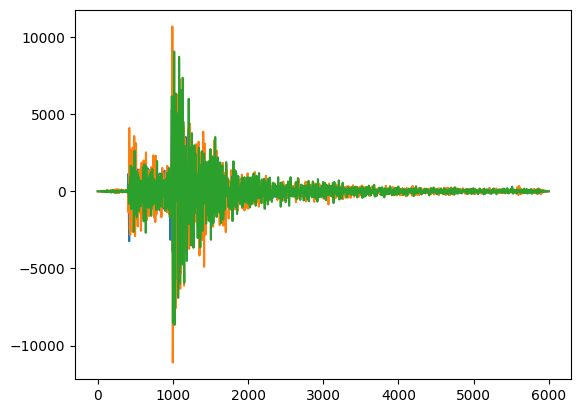

In [4]:
# Plot a sample waveform 
waveforms = stead.get_waveforms(1255657)
print(f"Waveforms.shape", waveforms.shape)

plt.plot(waveforms.T);

Loading all models...
✅ All models loaded successfully.

Loading SeisBench STEAD dataset...
Fetching and processing sample at index 235435...
✅ Data processed successfully. Final shape: (1, 6000, 3)
✅ Predictions generated. Plotting results...


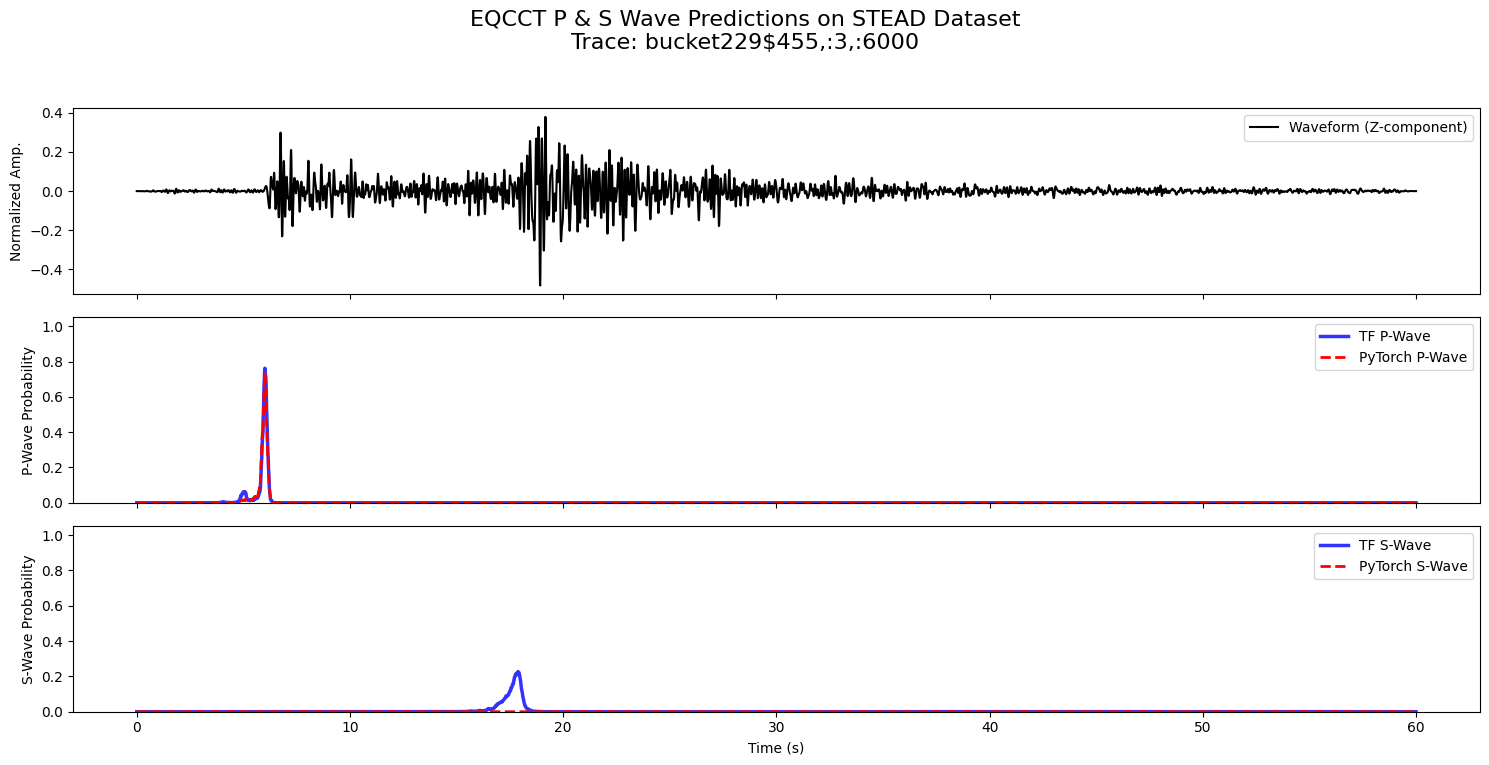

: 

In [ ]:
import torch
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple, Optional

# SeisBench for local datasets
import seisbench.data as sbd

# Import your model definition files
import predictor_tf
from predictor_pt_p import EQCCTModelP
from predictor_pt import EQCCTModelS

def load_all_models(tf_p: str, tf_s: str, pt_p: str, pt_s: str) -> Optional[Dict]:
    """Loads all four TF and PT models."""
    print("Loading all models...")
    try:
        modelP_tf, modelS_tf = predictor_tf.load_eqcct_model(tf_p, tf_s)
        
        modelP_pt = EQCCTModelP()
        modelP_pt.load_state_dict(torch.load(pt_p))
        modelP_pt.eval()

        modelS_pt = EQCCTModelS()
        modelS_pt.load_state_dict(torch.load(pt_s))
        modelS_pt.eval()

        print("✅ All models loaded successfully.")
        return {
            "tf_p": modelP_tf, "tf_s": modelS_tf,
            "pt_p": modelP_pt, "pt_s": modelS_pt
        }
    except Exception as e:
        print(f"❌ Error loading models: {e}")
        return None

def plot_all_results(model_input: np.ndarray, predictions: Dict, metadata: Dict):
    """Visualizes the waveform and all P and S predictions."""
    print("✅ Predictions generated. Plotting results...")
    
    time_axis = np.arange(model_input.shape[1]) / 100.0 # Use 100 Hz for time axis
    fig, axs = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
    
    # Panel 1: Waveform (Vertical Component)
    axs[0].plot(time_axis, model_input[0, :, 2], 'k', label='Waveform (Z-component)')
    axs[0].set_ylabel('Normalized Amp.')
    axs[0].legend(loc='upper right')
    
    # Panel 2: P-Wave Predictions
    axs[1].plot(time_axis, predictions['tf_p'], 'b-', label='TF P-Wave', linewidth=2.5, alpha=0.8)
    axs[1].plot(time_axis, predictions['pt_p'], 'r--', label='PyTorch P-Wave', linewidth=2)
    axs[1].set_ylabel('P-Wave Probability')
    axs[1].legend(loc='upper right')
    axs[1].set_ylim(0, 1.05)

    # Panel 3: S-Wave Predictions
    axs[2].plot(time_axis, predictions['tf_s'], 'b-', label='TF S-Wave', linewidth=2.5, alpha=0.8)
    axs[2].plot(time_axis, predictions['pt_s'], 'r--', label='PyTorch S-Wave', linewidth=2)
    axs[2].set_ylabel('S-Wave Probability')
    axs[2].set_xlabel('Time (s)')
    axs[2].legend(loc='upper right')
    axs[2].set_ylim(0, 1.05)

    title = f"EQCCT P & S Wave Predictions on STEAD Dataset\nTrace: {metadata['trace_name']}"
    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == '__main__':
    # --- Define Model Paths ---
    TF_P_PATH = 'ModelPS/test_trainer_024.h5'
    TF_S_PATH = 'ModelPS/test_trainer_021.h5'
    PT_P_PATH = 'ModelPS/modelP_fixed_bn.pth'
    PT_S_PATH = 'modelS_pytorch_direct.pth'

    # --- Load models once ---
    models = load_all_models(TF_P_PATH, TF_S_PATH, PT_P_PATH, PT_S_PATH)
    
    if models:
        # --- Load and Process Waveform from SeisBench STEAD ---
        print("\nLoading SeisBench STEAD dataset...")
        # IMPORTANT: Load data at 100 Hz to match the model's requirement.
        # This will automatically give us 6000 samples for a 60s window.
        # stead_data = sbd.STEAD(sampling_rate=100, component_order='ZNE')
        
        # Get the waveform data for a specific sample index
        example_index = 235435 # [235426, 235427, 235428, 235429, 235430, 235431, 235432, 235433, 235434, 235435, 1255660]
        print(f"Fetching and processing sample at index {example_index}...")
        waveform_data = stead.get_waveforms(example_index)
        metadata = stead.metadata.iloc[example_index].to_dict()

        # EQCCT expects E,N,Z order. The data was loaded as Z,N,E. We must reorder.
        # From (Z, N, E) to (E, N, Z)
        data = np.array([waveform_data[2], waveform_data[1], waveform_data[0]])

        # Normalize and reshape
        data /= np.max(np.abs(data))
        model_input = np.expand_dims(data.transpose(), axis=0).astype('float32')
        print(f"✅ Data processed successfully. Final shape: {model_input.shape}")

        # --- Run Inference ---
        tf_p_pred = models['tf_p'](model_input, training=False).numpy().flatten()
        tf_s_pred = models['tf_s'](model_input, training=False).numpy().flatten()
        
        with torch.no_grad():
            pt_p_pred = models['pt_p'](torch.from_numpy(model_input)).numpy().flatten()
            pt_s_pred = models['pt_s'](torch.from_numpy(model_input)).numpy().flatten()

        all_predictions = {
            "tf_p": tf_p_pred, "pt_p": pt_p_pred,
            "tf_s": tf_s_pred, "pt_s": pt_s_pred
        }
        
        # --- Plot the final results ---
        plot_all_results(model_input, all_predictions, metadata)